# Skin Disorder Prediction Project

**Dataset**: Dermatology Dataset

**Domain**: Healthcare

**Tasks**:
1. Data Analysis Report
2. Predictive Model for Skin Disease Classification
3. Suggestions for Doctors
4. Model Comparison
5. Challenges Faced

In [25]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore")

In [26]:
# Load Dataset
df = pd.read_csv(r"C:\Users\aysha\Capstone_Projects\data\PRCP-1028-Skin-Disorder-Prediction\dataset_35_dermatology (1).csv")
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [27]:
# Data Cleaning
df = df.replace('?', np.nan)
df = df.dropna()
df = df.astype(float)
df['class'] = df['class'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 358 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   erythema                                  358 non-null    float64
 1   scaling                                   358 non-null    float64
 2   definite_borders                          358 non-null    float64
 3   itching                                   358 non-null    float64
 4   koebner_phenomenon                        358 non-null    float64
 5   polygonal_papules                         358 non-null    float64
 6   follicular_papules                        358 non-null    float64
 7   oral_mucosal_involvement                  358 non-null    float64
 8   knee_and_elbow_involvement                358 non-null    float64
 9   scalp_involvement                         358 non-null    float64
 10  family_history                            3

## 🧠 Exploratory Data Analysis (EDA)

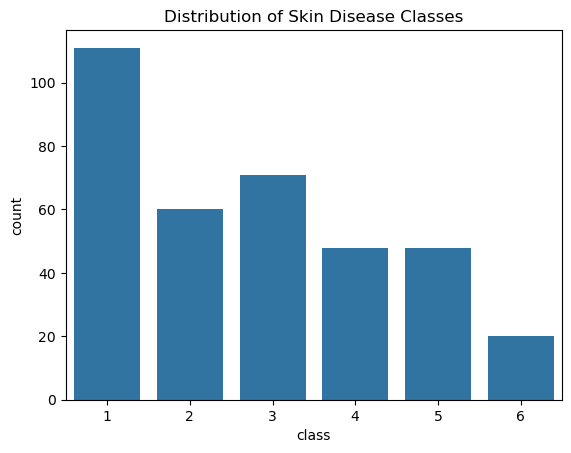

In [29]:
# Class distribution
sns.countplot(x='class', data=df)
plt.title("Distribution of Skin Disease Classes")
plt.show()

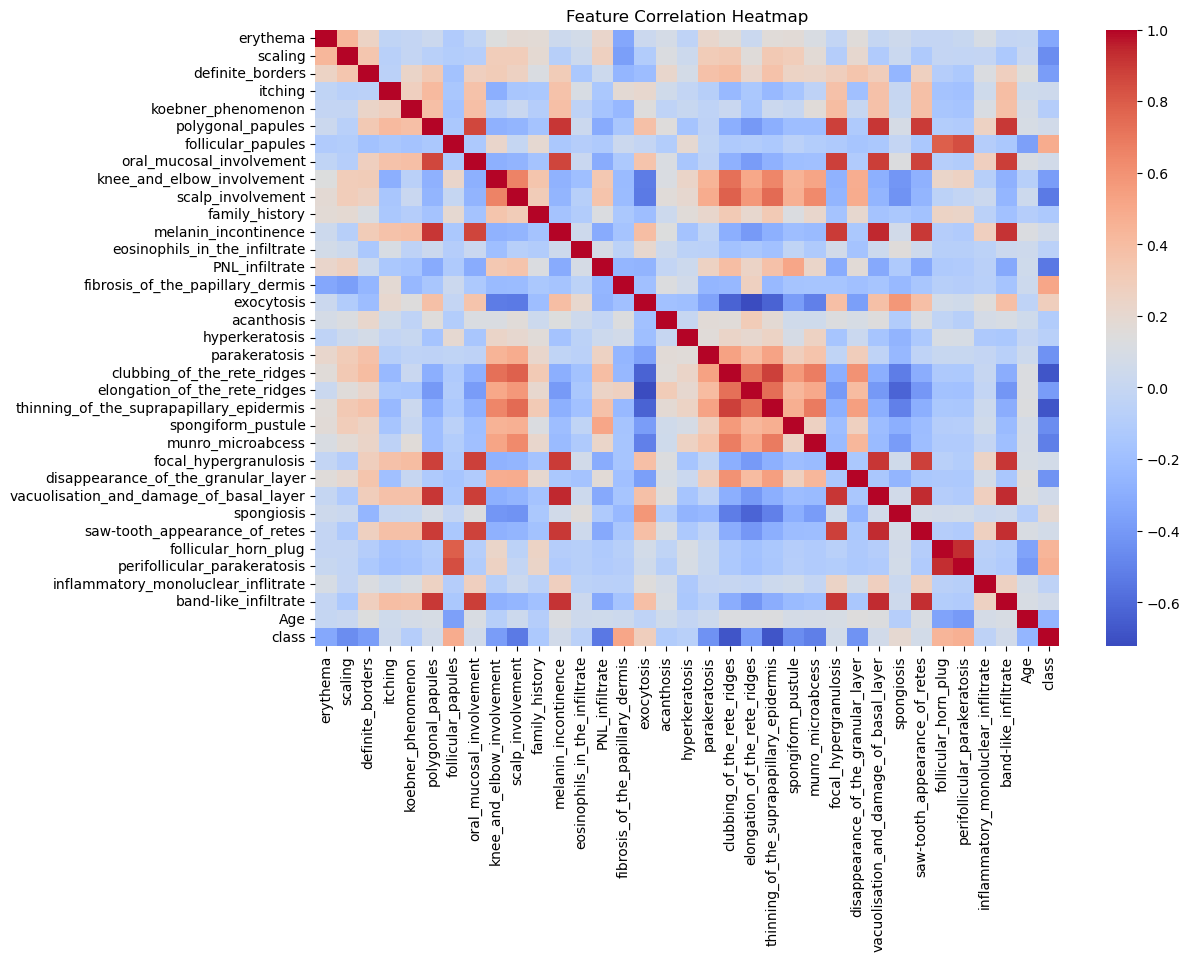

In [30]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## 🔍 Feature Engineering & Data Preparation

In [32]:
# Split features and target
X = df.drop("class", axis=1)
y = df["class"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## 🤖 Model Building & Evaluation

In [34]:
# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("\n" + "-"*50 + "\n")

Logistic Regression Accuracy: 0.9583
[[22  0  0  0  0  0]
 [ 0 12  0  2  0  0]
 [ 0  0 13  1  0  0]
 [ 0  0  0  8  0  0]
 [ 0  0  0  0 12  0]
 [ 0  0  0  0  0  2]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        22
           2       1.00      0.86      0.92        14
           3       1.00      0.93      0.96        14
           4       0.73      1.00      0.84         8
           5       1.00      1.00      1.00        12
           6       1.00      1.00      1.00         2

    accuracy                           0.96        72
   macro avg       0.95      0.96      0.95        72
weighted avg       0.97      0.96      0.96        72


--------------------------------------------------

KNN Accuracy: 0.9167
[[20  2  0  0  0  0]
 [ 0 11  0  3  0  0]
 [ 0  0 13  1  0  0]
 [ 0  0  0  8  0  0]
 [ 0  0  0  0 12  0]
 [ 0  0  0  0  0  2]]
              precision    recall  f1-score   support

           1       1.00      0.91    

## 📊 Model Comparison

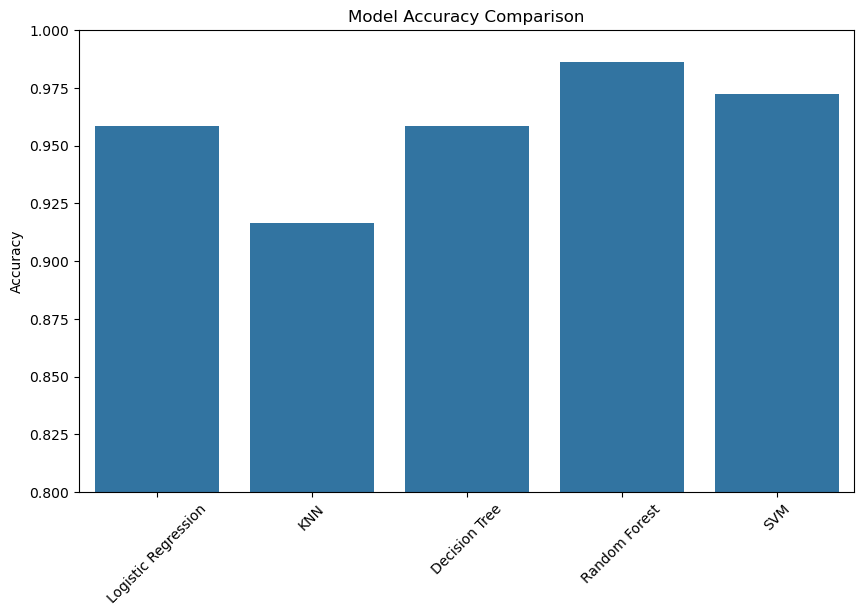

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=45)
plt.show()

## 🧾 Suggestions to Doctors
- Focus on features such as **scaling**, **itching**, and **erythema**, which are strongly correlated with specific disorders.
- Age and family history are also key predictors and should be collected thoroughly.
- Early detection using a decision support tool based on the Random Forest or SVM model (depending on accuracy) can help reduce biopsy requirements.
- Deploy the trained model into clinical tools to assist in diagnosis with just clinical and histopathological inputs.

## 🚧 Challenges Faced
- **Missing Data**: '?' values had to be cleaned.
- **Imbalanced Classes**: Some classes are underrepresented, which may affect model generalization.
- **No Feature Names in CSV**: Needed attribute context from project documentation.
- **Model Selection**: SVM and Random Forest gave best results, but hyperparameter tuning can further improve them.
- **Visual Interpretability**: Decision trees are easier for clinical interpretation, despite slightly lower accuracy.